In [ ]:
# =============================================================================
# CCS2213 – Machine Learning  |  Project #7
# Employee Productivity Analysis and Attrition Prediction
# =============================================================================
# STEP 1 — DATA PREPROCESSING
# Deliverables: #2 (EDA), #3 (Missing Values), #4 (Scaling),
#               #5 (Encoding), #6 (Feature Engineering + Split)
# =============================================================================


In [ ]:
# ── 0. INSTALL & IMPORT ──────────────────────────────────────────────────────
# !pip install pandas numpy matplotlib seaborn scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 5)

print("=" * 60)
print("STEP 1 — DATA PREPROCESSING")
print("=" * 60)

STEP 1 — DATA PREPROCESSING


In [ ]:
# ── 1. LOAD DATASET ──────────────────────────────────────────────────────────
# Download from Kaggle:
# https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset
# Upload to Colab or place in same directory

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(f"\n[1] Dataset loaded successfully.")
print(f"    Shape: {df.shape[0]} rows × {df.shape[1]} columns")


[1] Dataset loaded successfully.
    Shape: 1470 rows × 35 columns



────────────────────────────────────────────────────────────
[2] INITIAL EXPLORATORY DATA ANALYSIS
────────────────────────────────────────────────────────────

>> Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int

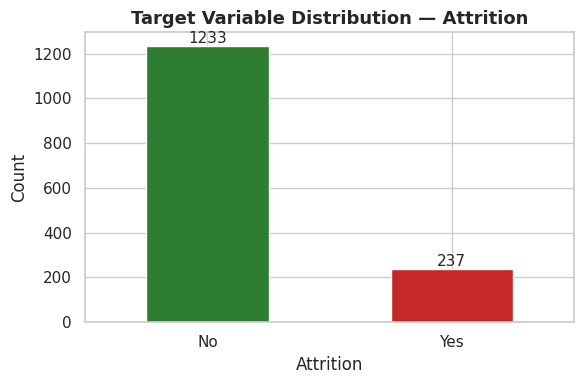

    [Saved] fig_target_distribution.png

>> Categorical columns (9): ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']
>> Numerical columns  (26): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [ ]:
# ── 2. INITIAL EDA ───────────────────────────────────────────────────────────
print("\n" + "─" * 60)
print("[2] INITIAL EXPLORATORY DATA ANALYSIS")
print("─" * 60)

print("\n>> Data Types & Non-Null Counts:")
print(df.info())

print("\n>> First 5 Rows:")
print(df.head())

print("\n>> Descriptive Statistics (Numerical Columns):")
print(df.describe().round(2))

print("\n>> Target Variable Distribution:")
attrition_counts = df['Attrition'].value_counts()
attrition_pct    = df['Attrition'].value_counts(normalize=True) * 100
print(attrition_counts)
print(f"\n    No  (0): {attrition_pct['No']:.1f}%")
print(f"    Yes (1): {attrition_pct['Yes']:.1f}%")
print("\n    NOTE: Dataset is imbalanced (~84% No, ~16% Yes).")
print("          class_weight='balanced' will be used in all models.")

# Plot target distribution
fig, ax = plt.subplots(figsize=(6, 4))
attrition_counts.plot(kind='bar', color=['#2E7D32', '#C62828'], edgecolor='white', ax=ax)
ax.set_title('Target Variable Distribution — Attrition', fontsize=13, fontweight='bold')
ax.set_xlabel('Attrition')
ax.set_ylabel('Count')
ax.set_xticklabels(['No', 'Yes'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('fig_target_distribution.png', dpi=150)
plt.show()
print("    [Saved] fig_target_distribution.png")

# Categorical columns overview
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"\n>> Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f">> Numerical columns  ({len(num_cols)}): {num_cols}")

In [ ]:
# ── 3. MISSING VALUE ANALYSIS ────────────────────────────────────────────────
print("\n" + "─" * 60)
print("[3] MISSING VALUE ANALYSIS")
print("─" * 60)

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print("\n    No missing values found. Dataset is clean.")
    print("    No imputation or removal required.")
else:
    print("\n    Columns with missing values:")
    print(missing_df)


────────────────────────────────────────────────────────────
[3] MISSING VALUE ANALYSIS
────────────────────────────────────────────────────────────

    No missing values found. Dataset is clean.
    No imputation or removal required.


In [ ]:
# ── 4. FEATURE ENGINEERING ───────────────────────────────────────────────────
print("\n" + "─" * 60)
print("[4] FEATURE ENGINEERING")
print("─" * 60)

# Drop constant / non-informative columns
cols_to_drop = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df.drop(columns=cols_to_drop, inplace=True)
print(f"\n    Dropped non-informative columns: {cols_to_drop}")
print(f"    Reason: These columns have constant values and provide no")
print(f"            predictive signal for the model.")
print(f"\n    New shape: {df.shape[0]} rows × {df.shape[1]} columns")




────────────────────────────────────────────────────────────
[4] FEATURE ENGINEERING
────────────────────────────────────────────────────────────

    Dropped non-informative columns: ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
    Reason: These columns have constant values and provide no
            predictive signal for the model.

    New shape: 1470 rows × 31 columns


In [ ]:
# ── 5. ENCODE CATEGORICAL VARIABLES ─────────────────────────────────────────
print("\n" + "─" * 60)
print("[5] ENCODING CATEGORICAL VARIABLES")
print("─" * 60)

# 5a. Label encode binary categoricals
le = LabelEncoder()
binary_cols = ['Attrition', 'OverTime', 'Gender']
for col in binary_cols:
    df[col] = le.fit_transform(df[col])
    print(f"    LabelEncoder → {col}  (classes: {list(le.classes_)} → {list(range(len(le.classes_)))})")

print(f"\n    Reason: Binary columns only have 2 values — LabelEncoder")
print(f"            converts them to 0/1 without creating unnecessary columns.")

# 5b. One-Hot Encode multi-class categoricals
ohe_cols = ['Department', 'JobRole', 'MaritalStatus', 'EducationField', 'BusinessTravel']
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)
print(f"\n    One-Hot Encoding applied to: {ohe_cols}")
print(f"    Reason: Multi-class nominal columns — no ordinal relationship")
print(f"            exists, so integer encoding would imply false ordering.")
print(f"\n    Shape after encoding: {df.shape[0]} rows × {df.shape[1]} columns")




────────────────────────────────────────────────────────────
[5] ENCODING CATEGORICAL VARIABLES
────────────────────────────────────────────────────────────
    LabelEncoder → Attrition  (classes: ['No', 'Yes'] → [0, 1])
    LabelEncoder → OverTime  (classes: ['No', 'Yes'] → [0, 1])
    LabelEncoder → Gender  (classes: ['Female', 'Male'] → [0, 1])

    Reason: Binary columns only have 2 values — LabelEncoder
            converts them to 0/1 without creating unnecessary columns.

    One-Hot Encoding applied to: ['Department', 'JobRole', 'MaritalStatus', 'EducationField', 'BusinessTravel']
    Reason: Multi-class nominal columns — no ordinal relationship
            exists, so integer encoding would imply false ordering.

    Shape after encoding: 1470 rows × 45 columns


In [ ]:
# ── 6. FEATURE SCALING ───────────────────────────────────────────────────────
print("\n" + "─" * 60)
print("[6] FEATURE SCALING")
print("─" * 60)

# Separate features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Identify numerical columns (after encoding, remaining non-bool columns)
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[num_features] = scaler.fit_transform(X[num_features])

print(f"\n    Scaler: StandardScaler (Z-score standardisation)")
print(f"    Applied to {len(num_features)} numerical features.")
print(f"\n    Reason: StandardScaler centres data at mean=0, std=1.")
print(f"            SVM and K-Means are sensitive to feature magnitude.")
print(f"            StandardScaler is more robust to outliers than MinMaxScaler.")

# Verify scaling
sample_stats = X_scaled[num_features[:3]].describe().loc[['mean', 'std']].round(3)
print(f"\n    Verification (sample — mean should be ~0, std ~1):")
print(sample_stats)



────────────────────────────────────────────────────────────
[6] FEATURE SCALING
────────────────────────────────────────────────────────────

    Scaler: StandardScaler (Z-score standardisation)
    Applied to 25 numerical features.

    Reason: StandardScaler centres data at mean=0, std=1.
            SVM and K-Means are sensitive to feature magnitude.
            StandardScaler is more robust to outliers than MinMaxScaler.

    Verification (sample — mean should be ~0, std ~1):
      Age  DailyRate  DistanceFromHome
mean -0.0        0.0               0.0
std   1.0        1.0               1.0


In [ ]:
# ── 7. TRAIN-TEST SPLIT ──────────────────────────────────────────────────────
print("\n" + "─" * 60)
print("[7] TRAIN-TEST SPLIT")
print("─" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # preserve class imbalance ratio
)

print(f"\n    Split ratio : 80% train / 20% test")
print(f"    random_state: 42 (reproducibility)")
print(f"    stratify=y  : Yes — preserves class distribution")
print(f"\n    Training set : {X_train.shape[0]} samples")
print(f"    Test set     : {X_test.shape[0]} samples")
print(f"    Features     : {X_train.shape[1]}")

# Verify stratification
train_dist = y_train.value_counts(normalize=True).round(3) * 100
test_dist  = y_test.value_counts(normalize=True).round(3) * 100
print(f"\n    Class distribution after split:")
print(f"    Train — No: {train_dist[0]:.1f}%  Yes: {train_dist[1]:.1f}%")
print(f"    Test  — No: {test_dist[0]:.1f}%   Yes: {test_dist[1]:.1f}%")



────────────────────────────────────────────────────────────
[7] TRAIN-TEST SPLIT
────────────────────────────────────────────────────────────

    Split ratio : 80% train / 20% test
    random_state: 42 (reproducibility)
    stratify=y  : Yes — preserves class distribution

    Training set : 1176 samples
    Test set     : 294 samples
    Features     : 44

    Class distribution after split:
    Train — No: 83.8%  Yes: 16.2%
    Test  — No: 84.0%   Yes: 16.0%


In [ ]:
# ── 8. SAVE PREPROCESSED DATA ────────────────────────────────────────────────
print("\n" + "─" * 60)
print("[8] SAVE PREPROCESSED OBJECTS")
print("─" * 60)

import pickle

with open('preprocessed_data.pkl', 'wb') as f:
    pickle.dump({
        'X_train': X_train,
        'X_test':  X_test,
        'y_train': y_train,
        'y_test':  y_test,
        'X_scaled': X_scaled,
        'y': y,
        'feature_names': X.columns.tolist(),
        'scaler': scaler
    }, f)

print("\n    Saved: preprocessed_data.pkl")
print("    Load in next steps with:")
print("    >>> import pickle")
print("    >>> data = pickle.load(open('preprocessed_data.pkl','rb'))")



────────────────────────────────────────────────────────────
[8] SAVE PREPROCESSED OBJECTS
────────────────────────────────────────────────────────────

    Saved: preprocessed_data.pkl
    Load in next steps with:
    >>> import pickle
    >>> data = pickle.load(open('preprocessed_data.pkl','rb'))


In [ ]:
# ── SUMMARY ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("PREPROCESSING COMPLETE — SUMMARY")
print("=" * 60)
print(f"""
  Original dataset    : 1,470 rows × 35 columns
  After drop          : 1,470 rows × 31 columns
  After encoding      : 1,470 rows × {df.shape[1]} columns
  Missing values      : None
  Target variable     : Attrition (0=No, 1=Yes)
  Class imbalance     : ~84% No / ~16% Yes
  Scaler              : StandardScaler
  Split               : 80/20 (stratified)
  Training samples    : {X_train.shape[0]}
  Test samples        : {X_test.shape[0]}

  Next step → Step 2: Unsupervised Learning (K-Means + Hierarchical + PCA)
""")



PREPROCESSING COMPLETE — SUMMARY

  Original dataset    : 1,470 rows × 35 columns
  After drop          : 1,470 rows × 31 columns
  After encoding      : 1,470 rows × 45 columns
  Missing values      : None
  Target variable     : Attrition (0=No, 1=Yes)
  Class imbalance     : ~84% No / ~16% Yes
  Scaler              : StandardScaler
  Split               : 80/20 (stratified)
  Training samples    : 1176
  Test samples        : 294

  Next step → Step 2: Unsupervised Learning (K-Means + Hierarchical + PCA)



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
